# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"

VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [3]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sklearn
print(sklearn.__version__)

1.8.0


### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [6]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [7]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [8]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

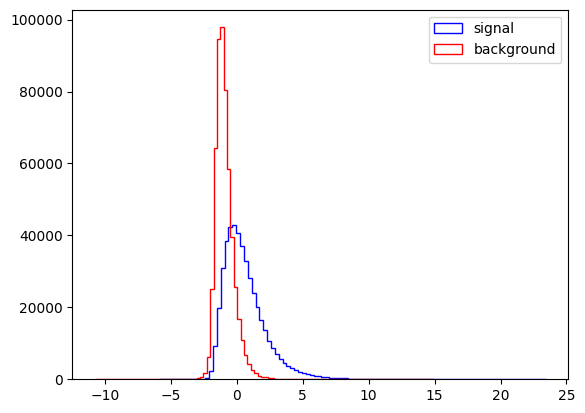

In [9]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

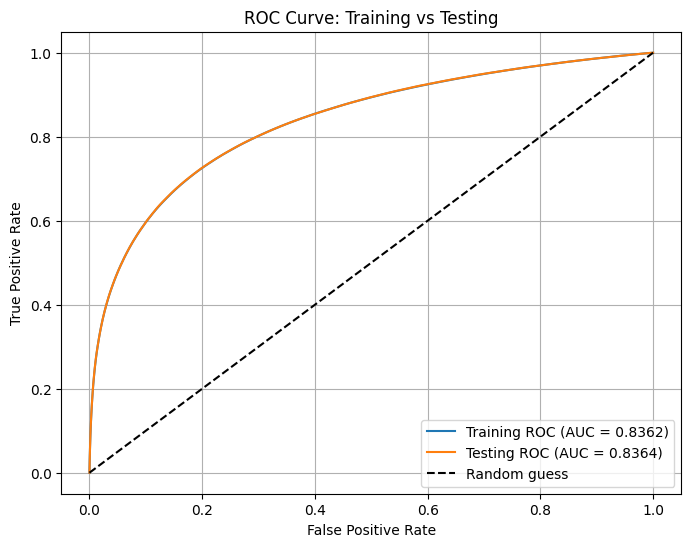

Training AUC = 0.8361729591588447
Testing AUC  = 0.8364009731285001


In [10]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test,  tpr_test,  _ = roc_curve(y_Test, test_scores)

auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test, tpr_test)

# Plotting  both on one figure
plt.figure(figsize=(8,6))
plt.plot(fpr_train, tpr_train, label=f"Training ROC (AUC = {auc_train:.4f})")
plt.plot(fpr_test, tpr_test, label=f"Testing ROC (AUC = {auc_test:.4f})")

# for reference line
plt.plot([0,1], [0,1], 'k--', label='Random guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Training vs Testing")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Training AUC =", auc_train)
print("Testing AUC  =", auc_test)

# The training and testing ROC curves are nearly identical with very similar AUC values i.e0.836.
# This indicates consistent performance on both datasets with no significant overfitting. So the model shows little to no bias and generalizes well.


#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

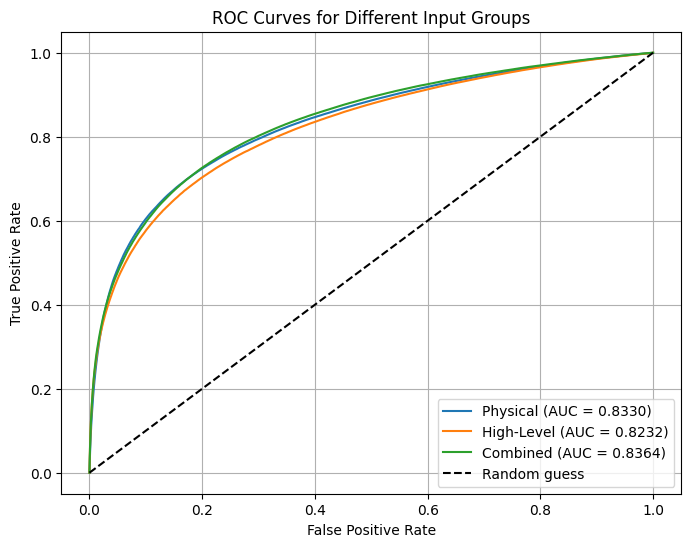

In [11]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import sklearn.discriminant_analysis as DA

# Defining  the three variable groups
physical_vars = VarNames[1:9]      
highlevel_vars = VarNames[9:]      
combined_vars = VarNames[1:]       

groups = [
    ("Physical", physical_vars),
    ("High-Level", highlevel_vars),
    ("Combined", combined_vars)
]

plt.figure(figsize=(8,6))

for name, cols in groups:
    fisher_model = DA.LinearDiscriminantAnalysis()
    fisher_model.fit(Train_Sample[cols], y_Train)

    scores = fisher_model.decision_function(Test_Sample[cols])
    fpr, tpr, _ = roc_curve(y_Test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0,1], [0,1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Different Input Groups")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# The combined input set raw + features gives the highest AUC and best overall performance.
# The raw variables perform reasonably well where the derived features alone are slightly weaker.
# This shows that combining all inputs improves the classifier’s ability to separate signal and background.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [12]:
#part a
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

model_logistic = LogisticRegression(max_iter=1000)
model_tree = DecisionTreeClassifier(max_depth=5)
model_forest = RandomForestClassifier(n_estimators=50, random_state=42)
print(model_logistic)
print(model_tree)
print(model_forest)

# Selected Logistic Regression, Decision Tree, and Random Forest for comparison.

LogisticRegression(max_iter=1000)
DecisionTreeClassifier(max_depth=5)
RandomForestClassifier(n_estimators=50, random_state=42)


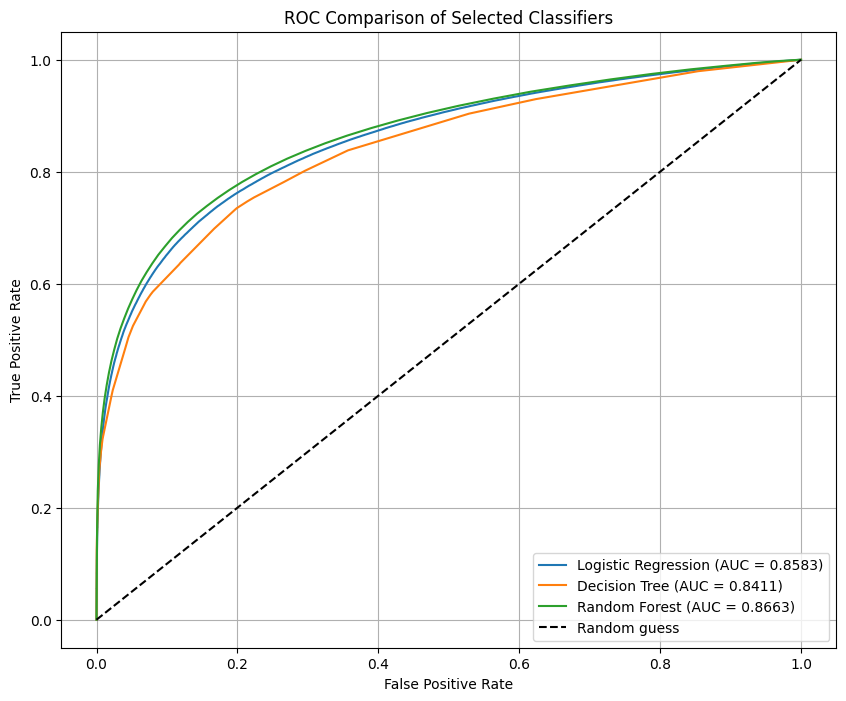

In [13]:
#part b
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def get_roc_info(classifier, title, sample_size=500000):
    classifier.fit(X_Train[:sample_size], y_Train[:sample_size])
    
    signal_scores = classifier.predict_proba(X_Test)[:, 1]
    
    fpr_values, tpr_values, _ = roc_curve(y_Test, signal_scores)
    auc_value = auc(fpr_values, tpr_values)
    
    return {
        "title": title,
        "fpr": fpr_values,
        "tpr": tpr_values,
        "auc": auc_value
    }
roc_results = []
roc_results.append(get_roc_info(model_logistic, "Logistic Regression"))
roc_results.append(get_roc_info(model_tree, "Decision Tree"))
roc_results.append(get_roc_info(model_forest, "Random Forest"))

plt.figure(figsize=(10, 8))

for result in roc_results:
    plt.plot(result["fpr"], result["tpr"],
             label=f'{result["title"]} (AUC = {result["auc"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison of Selected Classifiers")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
# The selected classifiers were compared using ROC curves and AUC values. This helps identify which model performs best.

In [14]:
#part c

import numpy as np

# Take the best model 
best_result = max(roc_results, key=lambda x: x["auc"])

best_fpr = best_result["fpr"]
best_tpr = best_result["tpr"]
best_label = best_result["title"]

lab5_cases = [(10, 100), (100, 1000), (1000, 10000), (10000, 100000)]

print(f"Using best classifier: {best_label}")

for Ns, Nb in lab5_cases:
    sigma_values = (best_tpr * Ns) / np.sqrt((best_tpr * Ns) + (best_fpr * Nb) + 1e-10)
    best_sigma = np.max(sigma_values)
    
    print(f"For Ns = {Ns}, Nb = {Nb}, maximum significance = {best_sigma:.3f}")

    # The best classifier was used to evaluate the Lab 5 scenarios. The maximum significance was computed using the ROC based TPR and FPR values.   

Using best classifier: Random Forest
For Ns = 10, Nb = 100, maximum significance = 1.780
For Ns = 100, Nb = 1000, maximum significance = 5.630
For Ns = 1000, Nb = 10000, maximum significance = 17.802
For Ns = 10000, Nb = 100000, maximum significance = 56.296


### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [15]:
#partb
from sklearn.metrics import roc_curve, auc, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

best_result = max(roc_results, key=lambda x: x["auc"])

best_name = best_result["title"]
best_fpr = best_result["fpr"]
best_tpr = best_result["tpr"]
best_auc = best_result["auc"]

if best_name == "Logistic Regression":
    best_clf = model_logistic
elif best_name == "Decision Tree":
    best_clf = model_tree
else:
    best_clf = model_forest

y_pred = best_clf.predict(X_Test)

precision_val = precision_score(y_Test, y_pred)
recall_val = recall_score(y_Test, y_pred)
f1_val = f1_score(y_Test, y_pred)
accuracy_val = accuracy_score(y_Test, y_pred)

sigma_values = best_tpr / np.sqrt(best_tpr + best_fpr + 1e-10)
max_sigma = np.max(sigma_values)

summary_table = pd.DataFrame([{
    "Model": best_name,
    "Precision": round(precision_val, 4),
    "Recall": round(recall_val, 4),
    "F1 Score": round(f1_val, 4),
    "Accuracy": round(accuracy_val, 4),
    "AUC": round(best_auc, 4),
    "Max Significance": round(max_sigma, 4)
}])

summary_table
# I the best classifier using key metrics Precision, Recall, F1, Accuracy, AUC and computed its maximal significance.

,Model,Precision,Recall,F1 Score,Accuracy,AUC,Max Significance
0,Random Forest,0.8224,0.7106,0.7624,0.7971,0.8663,0.7874
